                            OLS Regression Results                            
Dep. Variable:         SIMULATED_RATE   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     1.256
Date:                Fri, 25 Jul 2025   Prob (F-statistic):              0.158
Time:                        15:51:30   Log-Likelihood:                 408.16
No. Observations:                 177   AIC:                            -718.3
Df Residuals:                     128   BIC:                            -562.7
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3026    

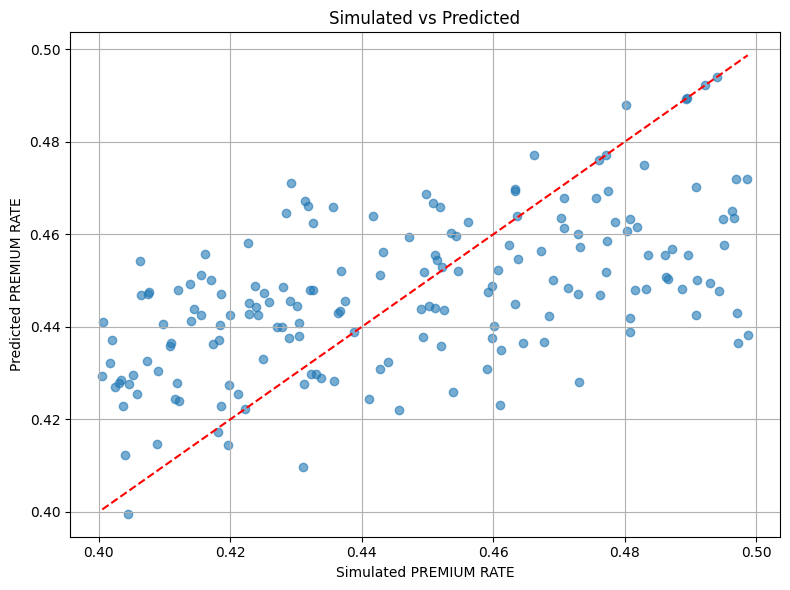

In [24]:
# Random Rate Regression
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load Data
file_path = r"K:\Kmis_Public\Clare\PREMIUM REGRESSION\PRIMARY REGRESSION DATA.xlsx"
df = pd.read_excel(file_path, sheet_name="PRIMARY DATA")

# Prepare Data
df['DATE BOUND'] = pd.to_datetime(df['DATE BOUND'])
df['MONTH_BOUND'] = df['DATE BOUND'].dt.to_period('M').astype(str)
df['HAZARD_SCORE'] = df['FIRE SCORE'].astype(str)
df['LATITUDE'] = pd.to_numeric(df['LATITUDE'])
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'])

# Limit Bands
limit_bins = [0, 1e6, 5e6, 10e6, np.inf]
limit_labels = ['0-1M', '1-5M', '5-10M', '>10M']
df['TIV_BAND'] = pd.cut(df['PROPERTY LIMIT'], bins=limit_bins, labels=limit_labels)
df['COV_A_BAND'] = pd.cut(df['POLICY LIMIT - COV A'], bins=limit_bins, labels=limit_labels)

# Simulate Random Rate between 0.4 - 0.5
np.random.seed(42)
df['SIMULATED_RATE'] = np.random.uniform(0.40, 0.50, size=len(df))

# Prepare X and Y
y_sim = df['SIMULATED_RATE']
X_base = df[['LATITUDE', 'LONGITUDE']]
X_cat = pd.get_dummies(df[['HAZARD_SCORE', 'MONTH_BOUND', 'TIV_BAND', 'COV_A_BAND']], drop_first=False)
X_sim = pd.concat([X_base, X_cat], axis=1)
X_sim = sm.add_constant(X_sim)
X_sim = X_sim.astype(float)

# Run Regression
model_sim = sm.OLS(y_sim, X_sim).fit()
print(model_sim.summary())

# Plot
y_pred_sim = model_sim.predict(X_sim)

plt.figure(figsize=(8, 6))
plt.scatter(y_sim, y_pred_sim, alpha=0.6)
plt.plot([y_sim.min(), y_sim.max()], [y_sim.min(), y_sim.max()], 'r--')
plt.xlabel("Simulated PREMIUM RATE")
plt.ylabel("Predicted PREMIUM RATE")
plt.title("Simulated vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:           PREMIUM_RATE   No. Observations:                  177
Model:                            GLM   Df Residuals:                      128
Model Family:                   Gamma   Df Model:                           48
Link Function:                    Log   Scale:                        0.078747
Method:                          IRLS   Log-Likelihood:                 871.27
Date:                Fri, 25 Jul 2025   Deviance:                       9.4976
Time:                        15:52:26   Pearson chi2:                     10.1
No. Iterations:                    15   Pseudo R-squ. (CS):             0.8743
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

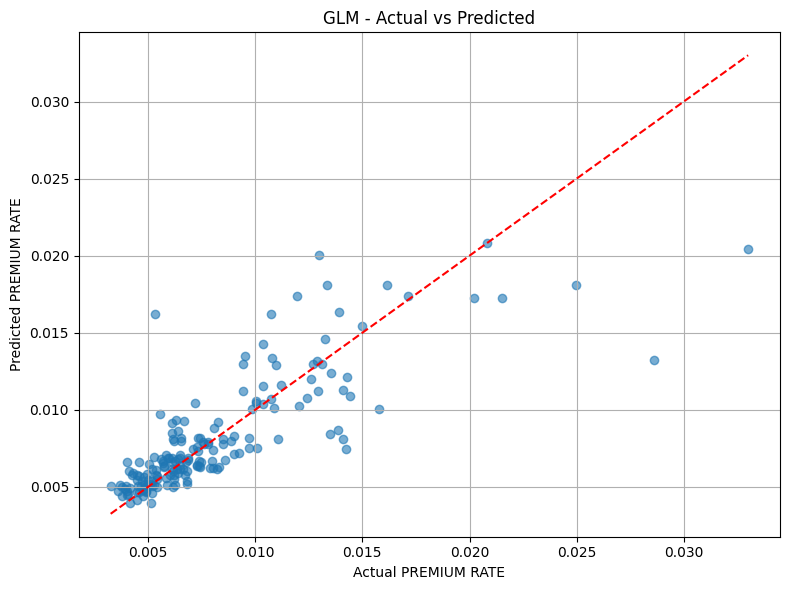

In [26]:
# General Linear Model Regression
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load Data
file_path = r"K:\Kmis_Public\Clare\PREMIUM REGRESSION\PRIMARY REGRESSION DATA.xlsx"
df = pd.read_excel(file_path, sheet_name="PRIMARY DATA")

# Prepare Data
df['DATE BOUND'] = pd.to_datetime(df['DATE BOUND'])
df['MONTH_BOUND'] = df['DATE BOUND'].dt.to_period('M').astype(str)
df['HAZARD_SCORE'] = df['FIRE SCORE'].astype(str)
df['LATITUDE'] = pd.to_numeric(df['LATITUDE'])
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'])

# Limit Bands
limit_bins = [0, 1e6, 5e6, 10e6, np.inf]
limit_labels = ['0-1M', '1-5M', '5-10M', '>10M']
df['TIV_BAND'] = pd.cut(df['PROPERTY LIMIT'], bins=limit_bins, labels=limit_labels)
df['COV_A_BAND'] = pd.cut(df['POLICY LIMIT - COV A'], bins=limit_bins, labels=limit_labels)

# GLM
df = df.rename(columns={"PREMIUM RATE (%)": "PREMIUM_RATE"})
formula = "PREMIUM_RATE ~ LATITUDE + LONGITUDE + C(HAZARD_SCORE) + C(MONTH_BOUND) + C(TIV_BAND) + C(COV_A_BAND)"

glm_model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_model.summary())

# Plot
y_actual = df['PREMIUM_RATE']
y_pred = glm_model.predict(df)

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.6)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.xlabel("Actual PREMIUM RATE")
plt.ylabel("Predicted PREMIUM RATE")
plt.title("GLM - Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()